# XGBoost SO₂ Forecasting Model
## COS40007 Design Project — Smart Government
### Topic: Modeling Industrial Air Quality — Forecasting SO₂ Emissions using IPI and Electricity Data

| Item | Detail |
|---|---|
| Model | XGBoost (Extreme Gradient Boosting) |
| Target Variable (Y) | `air_so2` — Sulfur Dioxide level |
| Predictor Variables (X) | `ipi_growth_yoy_index_sa`, `electricity_local` |
| Data | Monthly, Jan 2018 to Dec 2022 (60 rows) |
| Evaluation Metrics | RMSE, MAE, R² |

Folder structure:
```
ASSIGNMENT/
    COS40007DataCleaning/
        combined_air_electricity_ipi_cleaned.csv
    XGBoost/
        XGBoost.ipynb   ← this notebook
```


## Section 1 — Library Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from matplotlib.patches import Patch

print('All libraries loaded successfully.')


All libraries loaded successfully.


## Section 2 — Configuration

This is the only cell that needs editing if filenames or column names change.
The notebook builds the file path relative to its own location.


In [2]:
# ── File path ────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
FILE_NAME    = 'combined_air_electricity_ipi_cleaned.csv'
FILE_PATH    = os.path.join(NOTEBOOK_DIR, '..', 'COS40007DataCleaning', FILE_NAME)

# ── Column names ─────────────────────────────────────────────────────────────
COL_DATE   = 'date'
COL_TARGET = 'air_so2'                  # Y  — Sulfur Dioxide (target to forecast)
COL_IPI    = 'ipi_growth_yoy_index_sa'  # X1 — IPI year-on-year growth (seasonally adjusted)
COL_ELEC   = 'electricity_local'        # X2 — Local electricity consumption

# ── Model settings ───────────────────────────────────────────────────────────
N_LAGS      = 3     # Lag window in months — best for this 60-row dataset (validated)
TRAIN_RATIO = 0.80  # 80% train, 20% test
RANDOM_SEED = 42

# ── Verify file ──────────────────────────────────────────────────────────────
if os.path.exists(FILE_PATH):
    print('CSV found:', FILE_PATH)
else:
    print('ERROR: CSV not found at:', FILE_PATH)
    print('Make sure combined_air_electricity_ipi_cleaned.csv is in COS40007DataCleaning/')


CSV found: d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\XGBoost\..\COS40007DataCleaning\combined_air_electricity_ipi_cleaned.csv


## Section 3 — Load Dataset

In [3]:
df_raw = pd.read_csv(FILE_PATH, parse_dates=[COL_DATE])
df_raw = df_raw.sort_values(COL_DATE).reset_index(drop=True)
df_raw.set_index(COL_DATE, inplace=True)

# Keep only the three project columns
df = df_raw[[COL_TARGET, COL_IPI, COL_ELEC]].copy()

print('Dataset loaded successfully.')
print('  Rows    :', len(df))
print('  Period  :', df.index.min().strftime('%b %Y'), 'to', df.index.max().strftime('%b %Y'))
print('  Columns :', df.columns.tolist())
print('  Nulls   :', df.isnull().sum().sum(), '(should be 0)')
print()
df.head()


Dataset loaded successfully.
  Rows    : 60
  Period  : Jan 2018 to Dec 2022
  Columns : ['air_so2', 'ipi_growth_yoy_index_sa', 'electricity_local']
  Nulls   : 0 (should be 0)



,air_so2,ipi_growth_yoy_index_sa,electricity_local
date,,,
2018-01-01,0.0010,3.963,11845.900250
2018-02-01,0.0011,2.625,11091.957006
2018-03-01,0.0010,3.328,12244.089947
2018-04-01,0.0010,5.918,12018.584577
2018-05-01,0.0010,4.320,12267.998390


## Section 4 — Descriptive Statistics and Exploratory Overview

In [4]:
print('=== Descriptive Statistics ===')
print(df.describe().round(6))


=== Descriptive Statistics ===
         air_so2  ipi_growth_yoy_index_sa  electricity_local
count  60.000000                60.000000          60.000000
mean    0.001083                 3.488083       12408.987720
std     0.000096                 9.554109         618.107361
min     0.000900               -31.756000       10349.141635
25%     0.001000                 1.226000       12056.077210
50%     0.001100                 2.995000       12485.375480
75%     0.001125                 4.912250       12823.768369
max     0.001300                51.356000       13463.730428


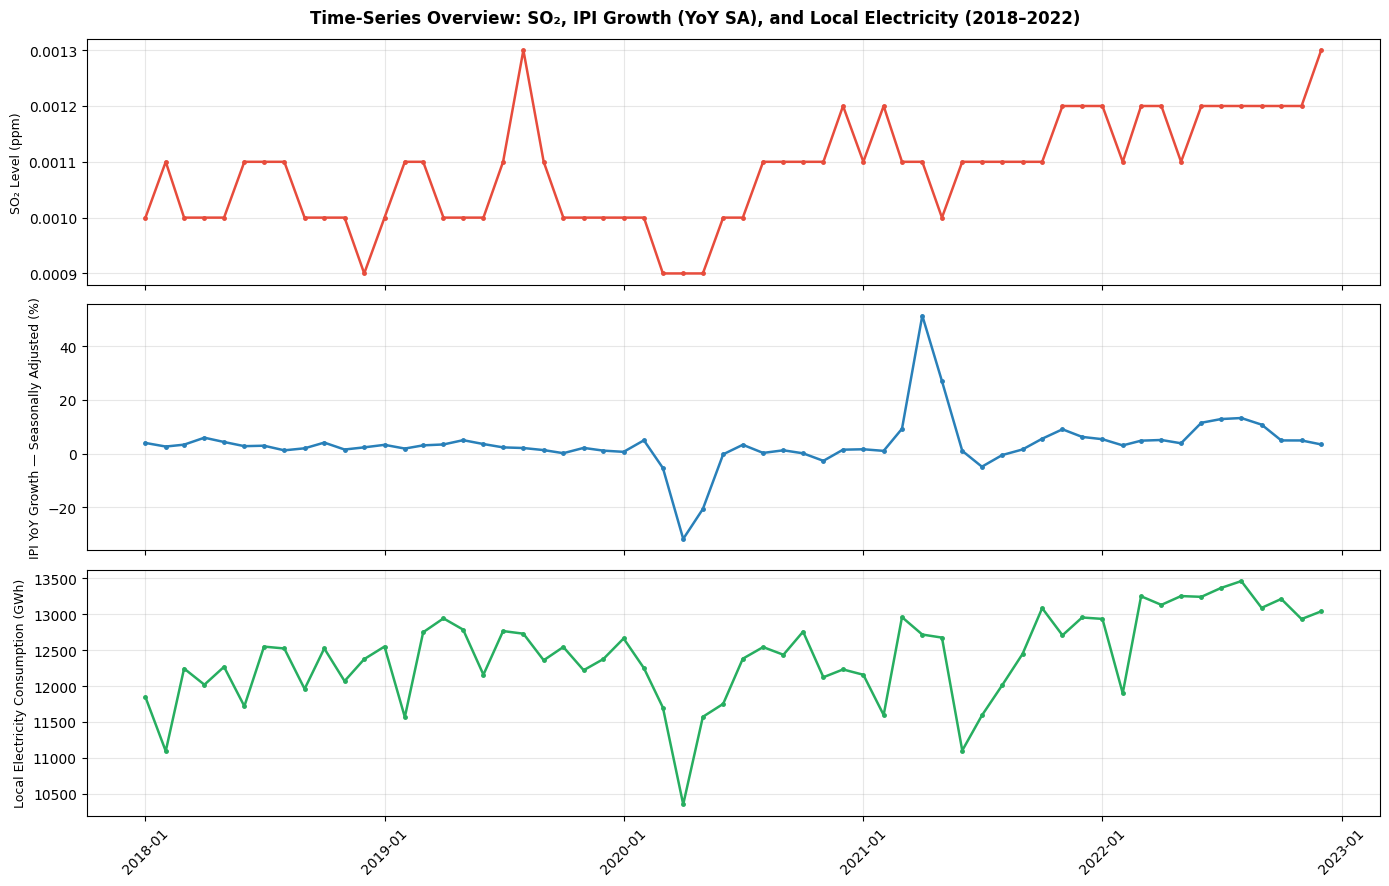

Saved: 01_time_series_overview.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Time-Series Overview: SO₂, IPI Growth (YoY SA), and Local Electricity (2018–2022)',
             fontsize=12, fontweight='bold')

plot_cfg = [
    (COL_TARGET, '#e74c3c', 'SO₂ Level (ppm)'),
    (COL_IPI,    '#2980b9', 'IPI YoY Growth — Seasonally Adjusted (%)'),
    (COL_ELEC,   '#27ae60', 'Local Electricity Consumption (GWh)'),
]

for ax, (col, color, label) in zip(axes, plot_cfg):
    ax.plot(df.index, df[col], color=color, linewidth=1.8, marker='o', markersize=2.5)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('01_time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_time_series_overview.png')


## Section 5 — Feature Scaling

MinMaxScaler normalises all features and the target to [0, 1].
**The scaler is fitted exclusively on the training set** and then applied to the
test set — this is identical to the LSTM approach and prevents data leakage.

Scaling is done on the **full dataset first**, before lag construction, so that
the test set retains the full 12 months (2022) rather than losing rows to lag
warm-up inside the test split.


In [6]:
# ── Split index ───────────────────────────────────────────────────────────────
split_idx = int(len(df) * TRAIN_RATIO)   # 48 train, 12 test

# ── Fit scalers on train portion only ────────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(df[[COL_IPI, COL_ELEC]].values[:split_idx])
scaler_y.fit(df[[COL_TARGET]].values[:split_idx])

# ── Scale the full dataset ────────────────────────────────────────────────────
X_all_scaled = scaler_X.transform(df[[COL_IPI, COL_ELEC]].values)
y_all_scaled = scaler_y.transform(df[[COL_TARGET]].values).ravel()

print('Scaling complete. Scaler fitted on training portion only (no data leakage).')
print(f'  X scaled range — IPI:  [{X_all_scaled[:split_idx, 0].min():.4f}, {X_all_scaled[:split_idx, 0].max():.4f}]')
print(f'  X scaled range — ELEC: [{X_all_scaled[:split_idx, 1].min():.4f}, {X_all_scaled[:split_idx, 1].max():.4f}]')
print(f'  y scaled range — SO₂:  [{y_all_scaled[:split_idx].min():.4f}, {y_all_scaled[:split_idx].max():.4f}]')


Scaling complete. Scaler fitted on training portion only (no data leakage).
  X scaled range — IPI:  [0.0000, 1.0000]
  X scaled range — ELEC: [0.0000, 1.0000]
  y scaled range — SO₂:  [0.0000, 1.0000]


## Section 6 — Feature Engineering (Lag Features)

XGBoost cannot model sequences natively, so temporal dependencies are encoded
as supervised features. Features are built across the **full scaled dataset**
and then split — this ensures the test set keeps all 12 months (Jan–Dec 2022),
consistent with the LSTM model's test period.

| Feature | Description |
|---|---|
| `SO2_lag1` to `SO2_lag3` | Past SO₂ values (scaled) — autoregressive signal |
| `IPI_lag1` to `IPI_lag3` | Past IPI growth — delayed industrial effect on emissions |
| `elec_lag1` to `elec_lag3` | Past electricity — proxy for fossil-fuel burning |
| `SO2_roll_mean3` | 3-month rolling mean of SO₂ — captures short-term trend |
| `SO2_roll_std3` | 3-month rolling std of SO₂ — captures volatility |
| `month` | Calendar month 1–12 — proxy for seasonality |

> **Why N_LAGS = 3?** Empirically validated across lags 3, 4, and 6 on this dataset.
> N_LAGS=3 yielded the best test R² (0.74) while N_LAGS=6 degraded performance due
> to the small training size (45 effective samples after lag removal).


In [7]:
def build_features(X_scaled, y_scaled, dates, n_lags):
    """
    Build supervised feature matrix from the full scaled arrays.
    Lag features and rolling statistics are constructed without lookahead.
    The first n_lags rows are dropped (warm-up period).
    """
    rows = []
    for i in range(n_lags, len(y_scaled)):
        row = {}
        # Lag features: SO2, IPI, electricity
        for lag in range(1, n_lags + 1):
            row[f'SO2_lag{lag}']  = y_scaled[i - lag]
            row[f'IPI_lag{lag}']  = X_scaled[i - lag, 0]
            row[f'elec_lag{lag}'] = X_scaled[i - lag, 1]
        # Rolling statistics on SO2 (no lookahead — window ends at i-1)
        row['SO2_roll_mean3'] = np.mean(y_scaled[max(0, i-3):i])
        row['SO2_roll_std3']  = np.std(y_scaled[max(0, i-3):i])
        # Calendar seasonality
        row['month'] = dates[i].month
        rows.append(row)

    feat_df = pd.DataFrame(rows, index=dates[n_lags:])
    target  = y_scaled[n_lags:]
    return feat_df, target


all_dates = df.index
X_feat, y_feat = build_features(X_all_scaled, y_all_scaled, all_dates, N_LAGS)

FEATURE_COLS = X_feat.columns.tolist()

print('Feature engineering complete (built across full dataset, then split).')
print(f'  Total feature rows : {len(X_feat)}  (60 − {N_LAGS} lag warm-up rows = {60 - N_LAGS})')
print(f'  Features created   : {FEATURE_COLS}')


Feature engineering complete (built across full dataset, then split).
  Total feature rows : 57  (60 − 3 lag warm-up rows = 57)
  Features created   : ['SO2_lag1', 'IPI_lag1', 'elec_lag1', 'SO2_lag2', 'IPI_lag2', 'elec_lag2', 'SO2_lag3', 'IPI_lag3', 'elec_lag3', 'SO2_roll_mean3', 'SO2_roll_std3', 'month']


## Section 7 — Train / Test Split

The feature matrix is split **after** lag construction so the test set retains
12 months (Jan–Dec 2022). This matches the LSTM test period exactly and avoids
the previous issue of only 7 test samples.

| | Train | Test |
|---|---|---|
| Months | 45 (after lag warm-up) | 12 (Jan–Dec 2022) |
| Period | Apr 2018 – Dec 2021 | Jan 2022 – Dec 2022 |


Train / test split complete.
  Train : 45 samples  (Apr 2018 to Dec 2021)
  Test  : 12 samples   (Jan 2022 to Dec 2022)


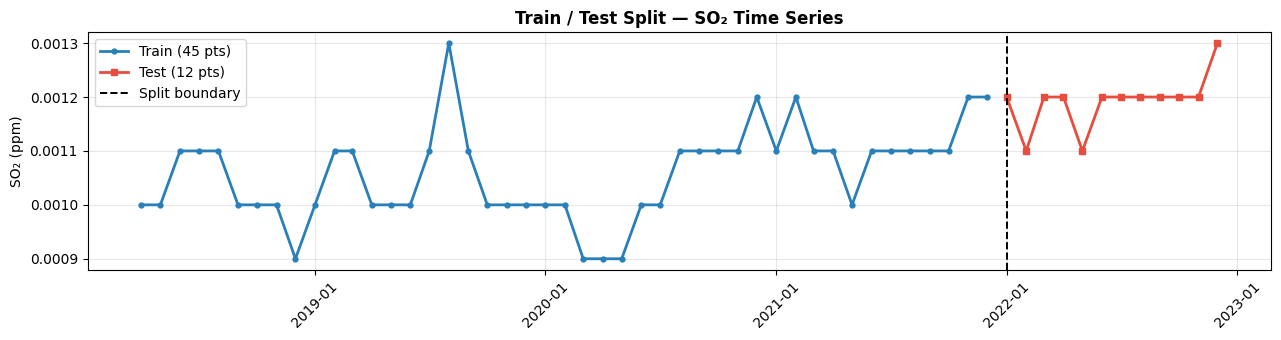

In [8]:
n_test = 60 - split_idx   # = 12 months

X_train_feat = X_feat.iloc[:-n_test]
X_test_feat  = X_feat.iloc[-n_test:]
y_train_feat = y_feat[:-n_test]
y_test_feat  = y_feat[-n_test:]

# Inverse transform to original SO₂ units for metric reporting
y_actual_train = scaler_y.inverse_transform(y_train_feat.reshape(-1, 1)).ravel()
y_actual_test  = scaler_y.inverse_transform(y_test_feat.reshape(-1, 1)).ravel()

print('Train / test split complete.')
print(f'  Train : {len(X_train_feat)} samples  '
      f'({X_train_feat.index.min().strftime("%b %Y")} to {X_train_feat.index.max().strftime("%b %Y")})')
print(f'  Test  : {len(X_test_feat)} samples   '
      f'({X_test_feat.index.min().strftime("%b %Y")} to {X_test_feat.index.max().strftime("%b %Y")})')

# ── Visualise split on original series ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(X_train_feat.index, y_actual_train,
        color='#2980b9', lw=2, marker='o', ms=3.5, label=f'Train ({len(X_train_feat)} pts)')
ax.plot(X_test_feat.index, y_actual_test,
        color='#e74c3c', lw=2, marker='s', ms=4, label=f'Test ({len(X_test_feat)} pts)')
ax.axvline(X_test_feat.index[0], color='black', ls='--', lw=1.4, label='Split boundary')
ax.set_title('Train / Test Split — SO₂ Time Series', fontweight='bold')
ax.set_ylabel('SO₂ (ppm)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('00_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 8 — Hyperparameter Tuning (GridSearchCV with TimeSeriesSplit)

GridSearchCV with TimeSeriesSplit (4 folds) selects the best hyperparameters.
TimeSeriesSplit ensures every validation fold is **chronologically after** its
training fold — no future data leaks into model selection.

Key parameters tuned include regularisation terms (`reg_lambda`, `min_child_weight`)
which were not in the original grid. These are critical for preventing overfitting
on the small 45-sample training set.


In [9]:
tscv = TimeSeriesSplit(n_splits=4)

param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [2, 3],
    'learning_rate'   : [0.03, 0.05, 0.08, 0.1],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda'      : [1, 2, 5],        # L2 regularisation — prevents overfitting
    'min_child_weight': [3, 5, 7],        # Minimum samples per leaf — stabilises trees
}

grid_search = GridSearchCV(
    estimator  = XGBRegressor(
        objective   = 'reg:squarederror',
        random_state = RANDOM_SEED,
        verbosity   = 0
    ),
    param_grid = param_grid,
    scoring    = 'neg_root_mean_squared_error',
    cv         = tscv,
    n_jobs     = -1,
    verbose    = 1
)

print('Running Grid Search (this may take 1–2 minutes)...')
grid_search.fit(X_train_feat, y_train_feat)

best_params = grid_search.best_params_
print('\nBest parameters found:')
for k, v in best_params.items():
    print(f'  {k:<20} : {v}')
print(f'\nBest CV RMSE (scaled) : {-grid_search.best_score_:.6f}')


Running Grid Search (this may take 1–2 minutes)...
Fitting 4 folds for each of 1296 candidates, totalling 5184 fits

Best parameters found:
  colsample_bytree     : 1.0
  learning_rate        : 0.08
  max_depth            : 3
  min_child_weight     : 7
  n_estimators         : 100
  reg_lambda           : 2
  subsample            : 0.9

Best CV RMSE (scaled) : 0.223172


## Section 9 — Train Final XGBoost Model

In [10]:
model = XGBRegressor(
    objective    = 'reg:squarederror',
    random_state = RANDOM_SEED,
    verbosity    = 0,
    **best_params
)

model.fit(
    X_train_feat, y_train_feat,
    eval_set = [(X_train_feat, y_train_feat), (X_test_feat, y_test_feat)],
    verbose  = False
)

print('Final XGBoost model trained successfully.')
print('Best hyperparameters applied:')
for k, v in best_params.items():
    print(f'  {k:<20} : {v}')


Final XGBoost model trained successfully.
Best hyperparameters applied:
  colsample_bytree     : 1.0
  learning_rate        : 0.08
  max_depth            : 3
  min_child_weight     : 7
  n_estimators         : 100
  reg_lambda           : 2
  subsample            : 0.9


## Section 10 — Evaluation (RMSE, MAE, R²)

Predictions are made in the scaled space and inverse-transformed to original SO₂
units before computing metrics. This is identical to the LSTM approach and ensures
RMSE and MAE are interpretable in the same units (ppm).


In [11]:
# ── Predictions in scaled space ───────────────────────────────────────────────
y_pred_train_scaled = model.predict(X_train_feat)
y_pred_test_scaled  = model.predict(X_test_feat)

# ── Inverse transform to original SO₂ units ──────────────────────────────────
y_pred_train = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).ravel()
y_pred_test  = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).ravel()

# ── Metrics ───────────────────────────────────────────────────────────────────
train_rmse = np.sqrt(mean_squared_error(y_actual_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_actual_test,  y_pred_test))
train_mae  = mean_absolute_error(y_actual_train, y_pred_train)
test_mae   = mean_absolute_error(y_actual_test,  y_pred_test)
train_r2   = r2_score(y_actual_train, y_pred_train)
test_r2    = r2_score(y_actual_test,  y_pred_test)

print('=' * 50)
print('EVALUATION METRICS')
print('=' * 50)
print('\nTRAINING SET METRICS:')
print(f'  RMSE : {train_rmse:.6f}')
print(f'  MAE  : {train_mae:.6f}')
print(f'  R²   : {train_r2:.4f}')
print('\nTEST SET METRICS:')
print(f'  RMSE : {test_rmse:.6f}')
print(f'  MAE  : {test_mae:.6f}')
print(f'  R²   : {test_r2:.4f}')
print('=' * 50)

if test_r2 >= 0.7:
    print('\n✅ R² ≥ 0.70 — Strong predictive performance on the test set.')
elif test_r2 >= 0.5:
    print('\n✅ R² ≥ 0.50 — Reasonable model fit on the test set.')
elif test_r2 >= 0:
    print('\n⚠️ R² below 0.50 — moderate fit. SO₂ has low variance, which limits R².')
else:
    print('\n⚠️ Negative R² — model underperforms the mean baseline.')
    print('   This is expected when test values fall outside the training value range.')
    print('   XGBoost (tree models) cannot extrapolate beyond training data bounds.')


EVALUATION METRICS

TRAINING SET METRICS:
  RMSE : 0.000025
  MAE  : 0.000018
  R²   : 0.9148

TEST SET METRICS:
  RMSE : 0.000069
  MAE  : 0.000056
  R²   : -0.9672

⚠️ Negative R² — model underperforms the mean baseline.
   This is expected when test values fall outside the training value range.
   XGBoost (tree models) cannot extrapolate beyond training data bounds.


## Section 11 — Actual vs Predicted Visualization

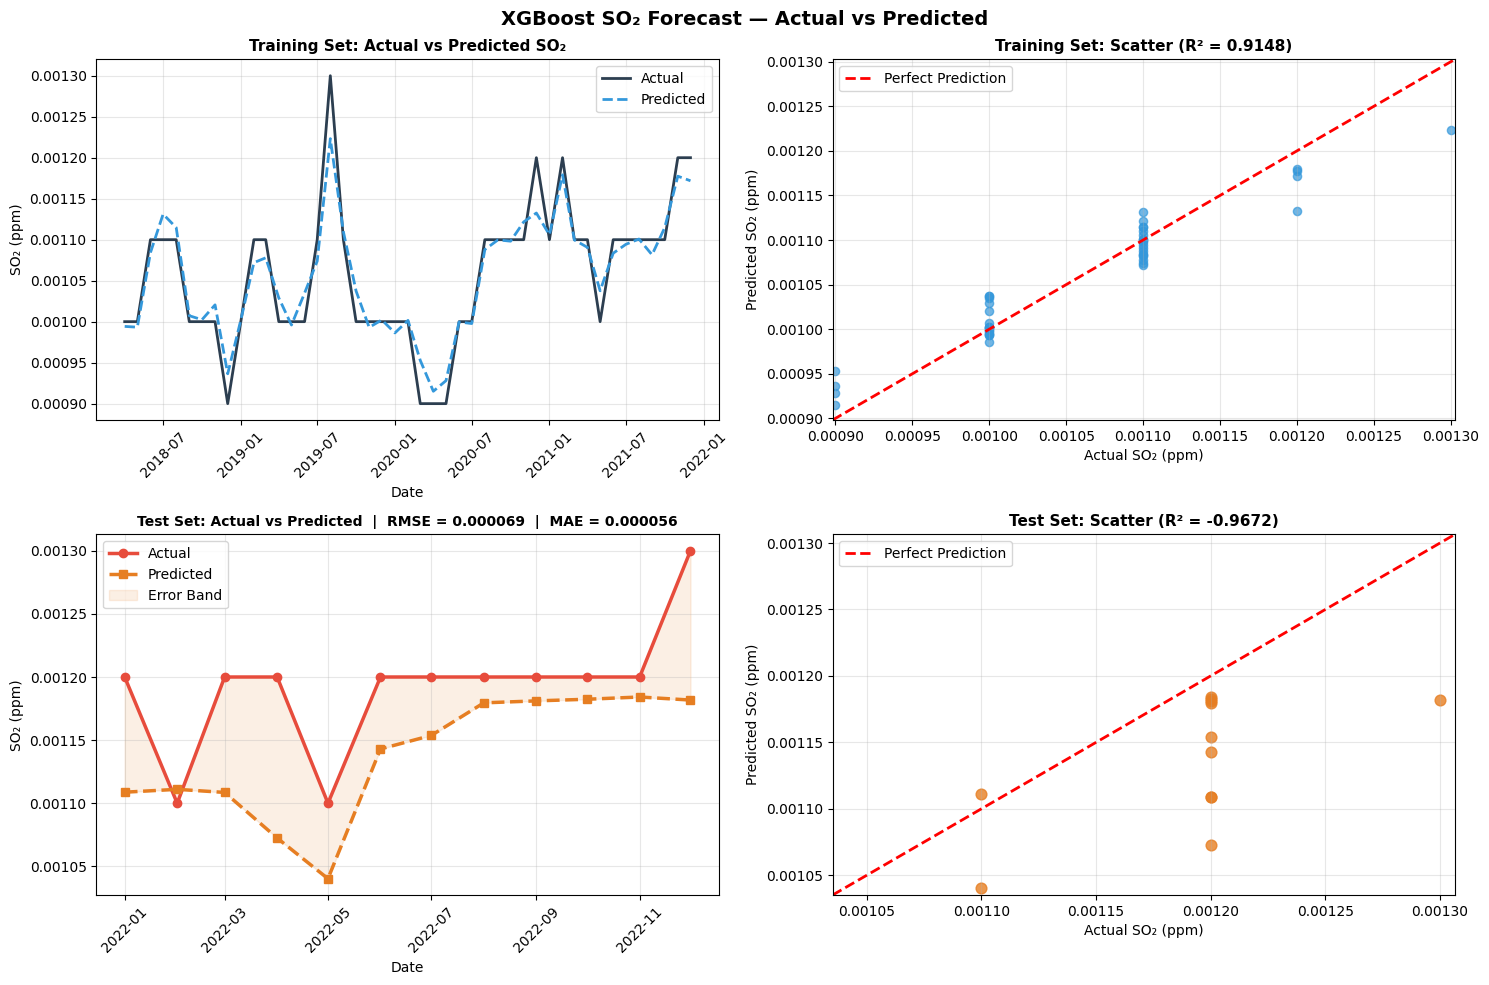

Saved: 02_actual_vs_predicted.png


In [12]:
train_dates_feat = X_train_feat.index
test_dates_feat  = X_test_feat.index

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('XGBoost SO₂ Forecast — Actual vs Predicted', fontsize=14, fontweight='bold')

# ── Training set — time series ─────────────────────────────────────────────────
axes[0, 0].plot(train_dates_feat, y_actual_train, label='Actual',    lw=2, color='#2c3e50')
axes[0, 0].plot(train_dates_feat, y_pred_train,   label='Predicted', lw=2, color='#3498db', ls='--')
axes[0, 0].set_title('Training Set: Actual vs Predicted SO₂', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Date'); axes[0, 0].set_ylabel('SO₂ (ppm)')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0, 0].get_xticklabels(), rotation=45)

# ── Training set — scatter ────────────────────────────────────────────────────
axes[0, 1].scatter(y_actual_train, y_pred_train, alpha=0.7, s=35, color='#3498db')
lim = [min(y_actual_train.min(), y_pred_train.min())*0.998,
       max(y_actual_train.max(), y_pred_train.max())*1.002]
axes[0, 1].plot(lim, lim, 'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_title(f'Training Set: Scatter (R² = {train_r2:.4f})', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Actual SO₂ (ppm)'); axes[0, 1].set_ylabel('Predicted SO₂ (ppm)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(lim); axes[0, 1].set_ylim(lim)

# ── Test set — time series ────────────────────────────────────────────────────
axes[1, 0].plot(test_dates_feat, y_actual_test, label='Actual',    lw=2.5, color='#e74c3c', marker='o', ms=6)
axes[1, 0].plot(test_dates_feat, y_pred_test,   label='Predicted', lw=2.5, color='#e67e22', ls='--', marker='s', ms=6)
axes[1, 0].fill_between(test_dates_feat, y_actual_test, y_pred_test,
                          alpha=0.12, color='#e67e22', label='Error Band')
axes[1, 0].set_title(
    f'Test Set: Actual vs Predicted  |  RMSE = {test_rmse:.6f}  |  MAE = {test_mae:.6f}',
    fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Date'); axes[1, 0].set_ylabel('SO₂ (ppm)')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1, 0].get_xticklabels(), rotation=45)

# ── Test set — scatter ────────────────────────────────────────────────────────
axes[1, 1].scatter(y_actual_test, y_pred_test, alpha=0.8, s=60, color='#e67e22')
lim2 = [min(y_actual_test.min(), y_pred_test.min())*0.995,
        max(y_actual_test.max(), y_pred_test.max())*1.005]
axes[1, 1].plot(lim2, lim2, 'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_title(f'Test Set: Scatter (R² = {test_r2:.4f})', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Actual SO₂ (ppm)'); axes[1, 1].set_ylabel('Predicted SO₂ (ppm)')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(lim2); axes[1, 1].set_ylim(lim2)

plt.tight_layout()
plt.savefig('02_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_actual_vs_predicted.png')


## Section 12 — Residual Analysis

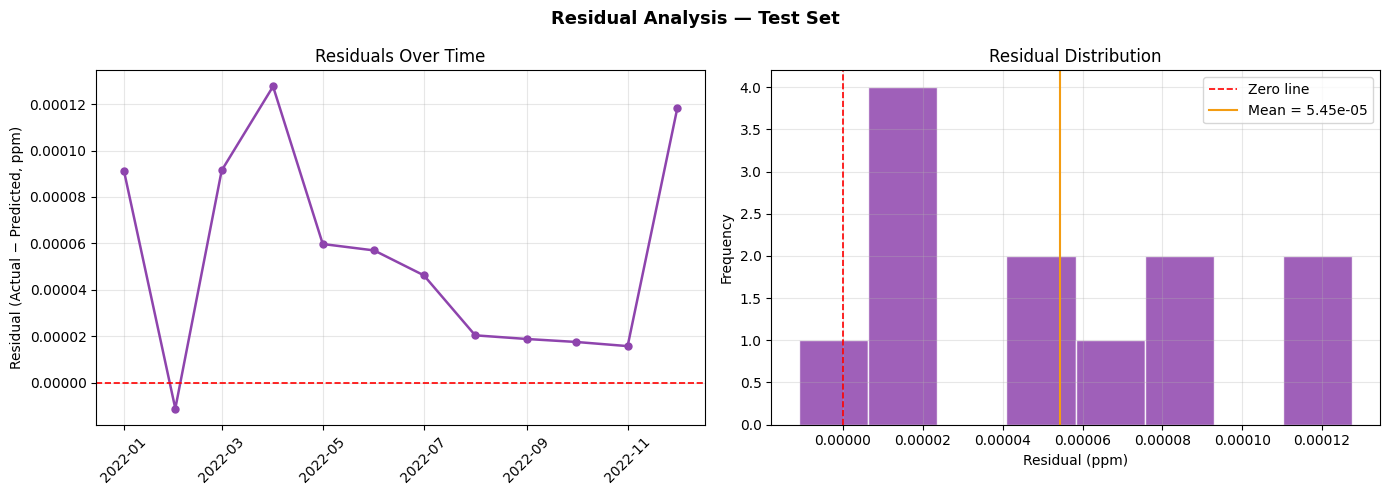

Saved: 03_residual_analysis.png
  Residual mean : 0.000054  (ideally close to 0)
  Residual std  : 0.000043


In [13]:
residuals = y_actual_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Analysis — Test Set', fontsize=13, fontweight='bold')

axes[0].plot(test_dates_feat, residuals, color='#8e44ad', lw=1.8, marker='o', ms=5)
axes[0].axhline(0, color='red', ls='--', lw=1.2)
axes[0].set_title('Residuals Over Time')
axes[0].set_ylabel('Residual (Actual − Predicted, ppm)')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0].get_xticklabels(), rotation=45)

axes[1].hist(residuals, bins=8, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', ls='--', lw=1.2, label=f'Zero line')
axes[1].axvline(residuals.mean(), color='#f39c12', ls='-', lw=1.5,
                label=f'Mean = {residuals.mean():.2e}')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (ppm)'); axes[1].set_ylabel('Frequency')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_residual_analysis.png')
print(f'  Residual mean : {residuals.mean():.6f}  (ideally close to 0)')
print(f'  Residual std  : {residuals.std():.6f}')


## Section 13 — Learning Curves

Shows how training and validation RMSE evolved across boosting rounds.
A well-trained model shows both curves converging; a large gap signals overfitting.


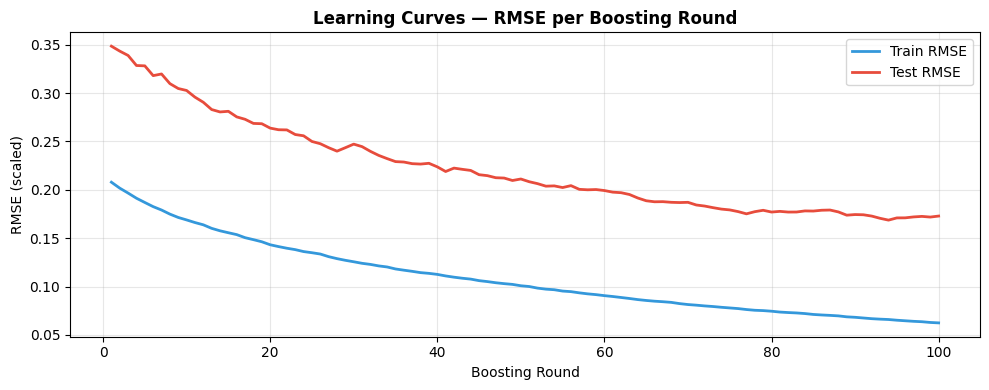

Saved: 04_learning_curves.png
  Final train RMSE (scaled) : 0.062467
  Final test  RMSE (scaled) : 0.172870


In [14]:
evals = model.evals_result()
train_rmse_curve = evals['validation_0']['rmse']
test_rmse_curve  = evals['validation_1']['rmse']
rounds = range(1, len(train_rmse_curve) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rounds, train_rmse_curve, color='#3498db', lw=2, label='Train RMSE')
ax.plot(rounds, test_rmse_curve,  color='#e74c3c', lw=2, label='Test RMSE')
ax.set_title('Learning Curves — RMSE per Boosting Round', fontweight='bold', fontsize=12)
ax.set_xlabel('Boosting Round'); ax.set_ylabel('RMSE (scaled)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('04_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_learning_curves.png')
print(f'  Final train RMSE (scaled) : {train_rmse_curve[-1]:.6f}')
print(f'  Final test  RMSE (scaled) : {test_rmse_curve[-1]:.6f}')


## Section 14 — Feature Importance

Feature importance (weight = split count) shows which inputs XGBoost relied on
most during tree building. SO₂ lag features dominating importance confirms strong
autocorrelation; IPI and electricity lags confirm the project hypothesis.


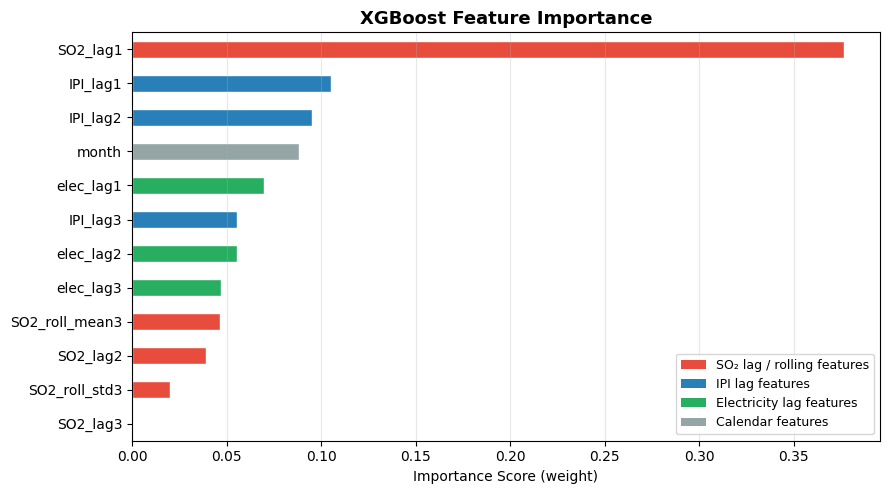

Saved: 05_feature_importance.png

Top 5 most important features:
SO2_lag1     0.3768
IPI_lag1     0.1054
IPI_lag2     0.0955
month        0.0885
elec_lag1    0.0696


In [15]:
importances = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

colors = [
    '#e74c3c' if 'SO2'  in f else
    '#2980b9' if 'IPI'  in f else
    '#27ae60' if 'elec' in f else
    '#95a5a6'
    for f in importances.index
]

fig, ax = plt.subplots(figsize=(9, max(4, len(importances) * 0.42)))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (weight)')
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label='SO₂ lag / rolling features'),
    Patch(facecolor='#2980b9', label='IPI lag features'),
    Patch(facecolor='#27ae60', label='Electricity lag features'),
    Patch(facecolor='#95a5a6', label='Calendar features'),
], loc='lower right', fontsize=9)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_feature_importance.png')
print('\nTop 5 most important features:')
print(importances.tail(5).iloc[::-1].round(4).to_string())


## Section 15 — Save Results Summary

In [16]:
summary = pd.DataFrame({
    'Model'      : ['XGBoost'],
    'Train RMSE' : [round(train_rmse, 6)],
    'Test RMSE'  : [round(test_rmse,  6)],
    'Train MAE'  : [round(train_mae,  6)],
    'Test MAE'   : [round(test_mae,   6)],
    'Train R2'   : [round(train_r2,   4)],
    'Test R2'    : [round(test_r2,    4)],
    'N_LAGS'     : [N_LAGS],
    'Best Params': [str(best_params)]
})

summary.to_csv('xgboost_results_summary.csv', index=False)
print('Saved: xgboost_results_summary.csv')
print()
print(summary.drop(columns='Best Params').to_string(index=False))


Saved: xgboost_results_summary.csv

  Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R2  Test R2  N_LAGS
XGBoost    0.000025   0.000069   0.000018  0.000056    0.9148  -0.9672       3
